# Diabetes Prediction Modeling

Pima Indians Diabetes Database: binary classification to predict diabetes (Outcome: 1) vs no diabetes (Outcome: 0) from clinical measurements.

**Plan:** Data profiling and zero-to-NaN handling, leakage-safe pipelines, stratified CV + holdout evaluation, SHAP interpretation, and medical plausibility review.

## 1. Data Loading and Profiling

Load the dataset, convert biologically implausible zeros to NaN, and quantify missingness.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("diabetes.csv")
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
print("\nColumns:", list(df_raw.columns))
print("\nOutcome distribution:")
print(df_raw["Outcome"].value_counts().sort_index())
print("\nFirst rows:")
df_raw.head()

Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

First rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Columns where 0 is biologically implausible (treat as missing)
ZERO_AS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

def convert_implausible_zeros(df, cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df.loc[df[col] == 0, col] = np.nan
    return df

df = convert_implausible_zeros(df_raw, ZERO_AS_MISSING)
print("After converting implausible zeros to NaN:")
print(df[ZERO_AS_MISSING].isna().sum())

After converting implausible zeros to NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [3]:
# Missingness summary
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
print("Missingness by column:")
print(missing_df[missing_df["count"] > 0])

Missingness by column:
               count   pct
Glucose            5   0.7
BloodPressure     35   4.6
SkinThickness    227  29.6
Insulin          374  48.7
BMI               11   1.4


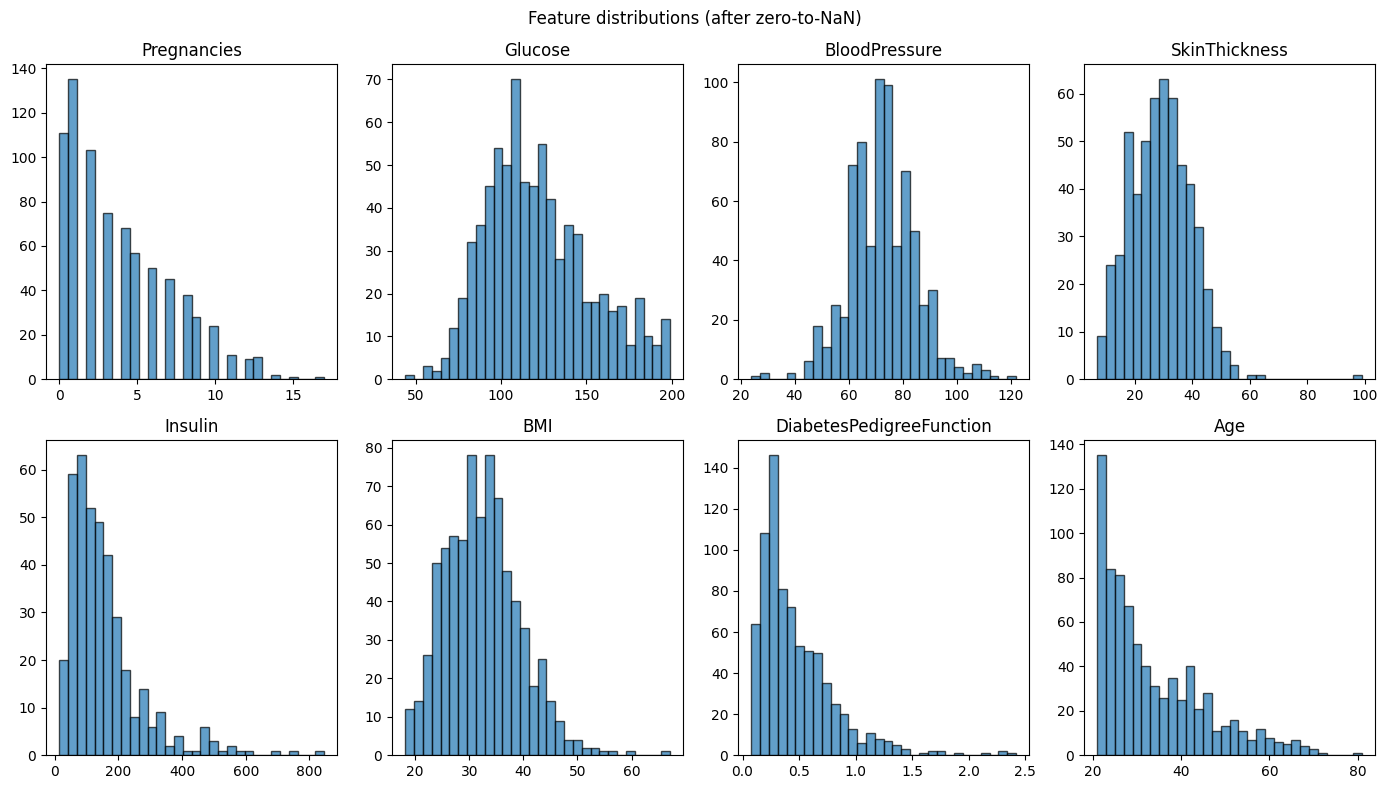

In [4]:
# Feature distributions and outliers
feature_cols = [c for c in df.columns if c != "Outcome"]
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor="black", alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
plt.suptitle("Feature distributions (after zero-to-NaN)")
plt.tight_layout()
plt.show()

## 2. Preprocessing and Model Pipelines

Leakage-safe pipelines: imputation and scaling inside CV. Logistic regression (with scaling) and tree-based models (Random Forest, XGBoost).

In [7]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    recall_score, precision_score, f1_score, balanced_accuracy_score,
    roc_curve, precision_recall_curve
)
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42
FEATURE_COLS = [c for c in df.columns if c != "Outcome"]
X = df[FEATURE_COLS]
y = df["Outcome"].astype(int)

# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train size:", len(X_train), "Test size:", len(X_test))

Train size: 614 Test size: 154


In [8]:
# Pipelines with imputation inside (no leakage)
# Logistic regression: impute + scale
pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"))
])

# Random Forest: impute only (trees don't need scaling)
pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
])

# XGBoost: impute only (skip if xgboost unavailable, e.g. missing libomp on Mac)
if HAS_XGB:
    pipe_xgb = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"))
    ])
    pipelines = {"Logistic Regression": pipe_lr, "Random Forest": pipe_rf, "XGBoost": pipe_xgb}
else:
    pipelines = {"Logistic Regression": pipe_lr, "Random Forest": pipe_rf}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 3. Model Evaluation

Stratified 5-fold CV for model comparison, then holdout test evaluation. Metrics: ROC-AUC, PR-AUC, recall, precision, F1, balanced accuracy.

In [9]:
# Cross-validation ROC-AUC
cv_scores = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_scores[name] = scores
    print(f"{name}: ROC-AUC = {scores.mean():.3f} (+/- {scores.std()*2:.3f})")

Logistic Regression: ROC-AUC = 0.844 (+/- 0.032)
Random Forest: ROC-AUC = 0.821 (+/- 0.048)


In [10]:
# Fit all models on full training set and evaluate on holdout
results = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "recall": recall_score(y_test, pred, zero_division=0),
        "precision": precision_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_test, pred)
    })

results_df = pd.DataFrame(results).set_index("model")
print("Holdout test set performance:")
results_df

Holdout test set performance:


,roc_auc,pr_auc,recall,precision,f1,balanced_acc
model,,,,,,
Logistic Regression,0.812593,0.672659,0.703704,0.603175,0.649573,0.726852
Random Forest,0.811019,0.677036,0.574074,0.659574,0.613861,0.707037


In [11]:
# Select best model by ROC-AUC and show confusion matrix
best_model_name = results_df["roc_auc"].idxmax()
best_pipe = pipelines[best_model_name]
print(f"Best model (by ROC-AUC): {best_model_name}")

y_pred = best_pipe.predict(X_test)
print("\nConfusion matrix (default threshold 0.5):")
print(confusion_matrix(y_test, y_pred))
print("\n(rows: true, cols: predicted; [0,0]=TN, [0,1]=FP, [1,0]=FN, [1,1]=TP)")

Best model (by ROC-AUC): Logistic Regression

Confusion matrix (default threshold 0.5):
[[75 25]
 [16 38]]

(rows: true, cols: predicted; [0,0]=TN, [0,1]=FP, [1,0]=FN, [1,1]=TP)


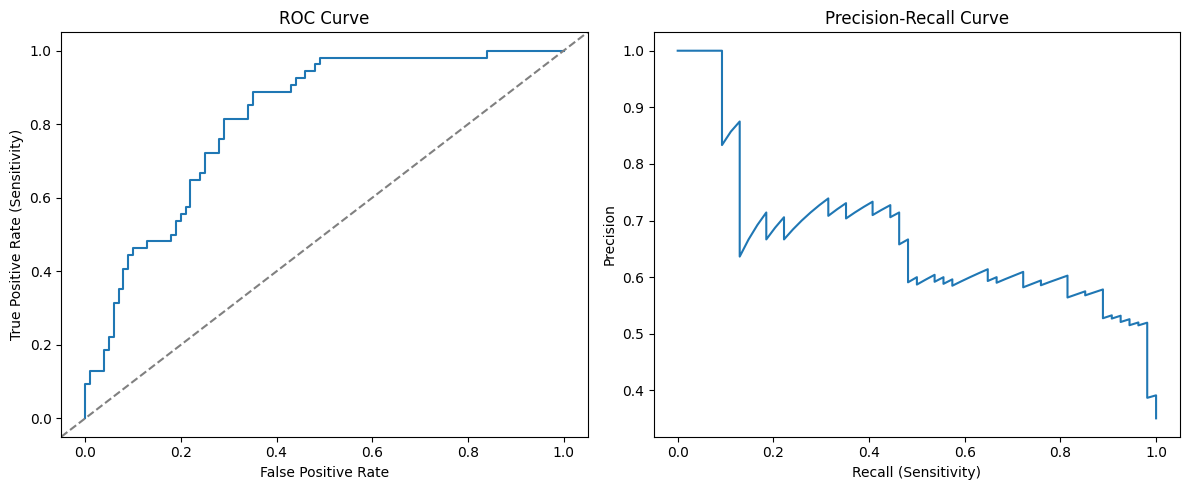

In [12]:
# Threshold analysis: for screening, favor sensitivity
proba = best_pipe.predict_proba(X_test)[:, 1]
fpr, tpr, thresh = roc_curve(y_test, proba)
prec, rec, thresh_pr = precision_recall_curve(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Sensitivity)")
axes[0].set_title("ROC Curve")
axes[0].axline((0, 0), slope=1, color="gray", linestyle="--")

axes[1].plot(rec, prec)
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

In [13]:
# Threshold sweep: sensitivity vs specificity
thresholds = np.linspace(0.1, 0.9, 17)
sweep = []
for t in thresholds:
    pred_t = (proba >= t).astype(int)
    sweep.append({
        "threshold": t,
        "sensitivity": recall_score(y_test, pred_t, zero_division=0),
        "specificity": recall_score(1 - y_test, 1 - pred_t, zero_division=0),
        "precision": precision_score(y_test, pred_t, zero_division=0)
    })
sweep_df = pd.DataFrame(sweep)
print("Threshold analysis (screening favors higher sensitivity):")
sweep_df.round(3)

Threshold analysis (screening favors higher sensitivity):


,threshold,sensitivity,specificity,precision
0,0.10,0.981,0.24,0.411
1,0.15,0.981,0.33,0.442
2,0.20,0.981,0.50,0.515
3,0.25,0.926,0.56,0.532
4,0.30,0.889,0.60,0.545
5,0.35,0.889,0.64,0.571
6,0.40,0.833,0.66,0.570
7,0.45,0.778,0.71,0.592
8,0.50,0.704,0.75,0.603
9,0.55,0.630,0.78,0.607


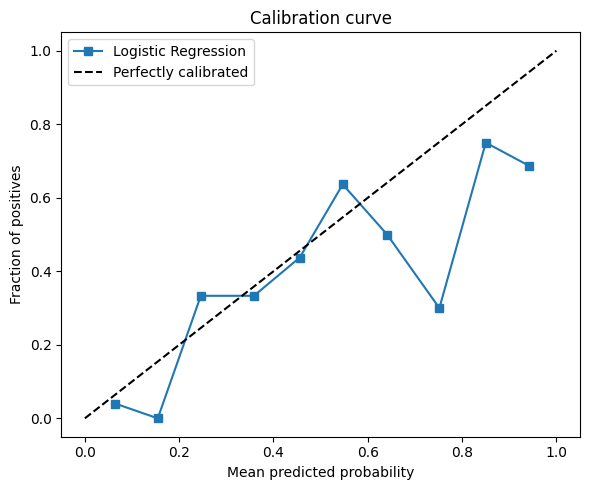

In [14]:
# Calibration: reliability diagram
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 5))
prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)
ax.plot(prob_pred, prob_true, "s-", label=best_model_name)
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curve")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Model Interpretation: SHAP and Feature Importance

Compute SHAP values on the best model. Global summary, mean absolute SHAP, dependence plots, and local explanations for representative cases (TP, FP, TN, FN).

In [16]:
import shap

# Prepare data: use same preprocessing as fitted pipeline (imputer already fit during pipeline.fit)
imputer = best_pipe.named_steps["imputer"]
X_train_imp = imputer.transform(X_train)
X_test_imp = imputer.transform(X_test)

if "scaler" in best_pipe.named_steps:
    scaler = best_pipe.named_steps["scaler"]
    X_train_for_shap = scaler.transform(X_train_imp)
    X_test_for_shap = scaler.transform(X_test_imp)
else:
    X_train_for_shap = X_train_imp
    X_test_for_shap = X_test_imp

model = best_pipe.named_steps["clf"]

In [17]:
# SHAP explainer (TreeExplainer for tree models, else LinearExplainer)
if best_model_name in ["Random Forest", "XGBoost"]:
    explainer = shap.TreeExplainer(model, X_train_for_shap, feature_names=FEATURE_COLS)
    shap_values = explainer.shap_values(X_test_for_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # class 1 (diabetes)
else:
    explainer = shap.LinearExplainer(model, X_train_for_shap, feature_names=FEATURE_COLS)
    shap_values = explainer.shap_values(X_test_for_shap)

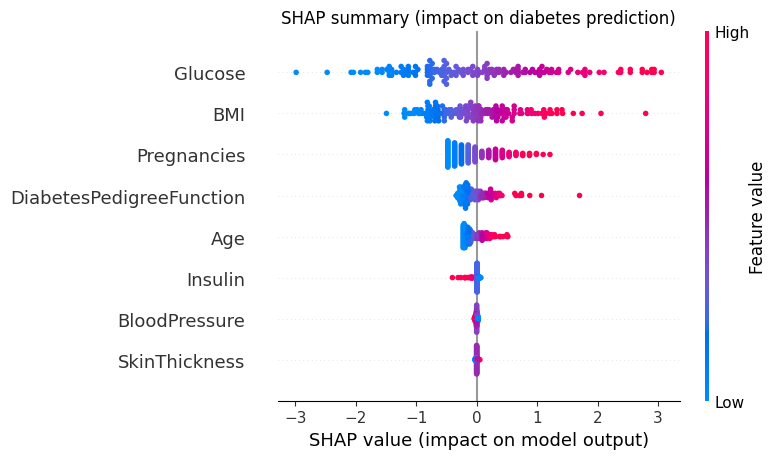

In [18]:
# Global SHAP summary (beeswarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_for_shap, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP summary (impact on diabetes prediction)")
plt.tight_layout()
plt.show()

In [19]:
# Mean absolute SHAP (feature importance ranking)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)
print("Mean absolute SHAP (feature importance):")
print(importance_df.to_string(index=False))

Mean absolute SHAP (feature importance):
                 feature  mean_abs_shap
                 Glucose       1.016384
                     BMI       0.583438
             Pregnancies       0.337128
DiabetesPedigreeFunction       0.214506
                     Age       0.159356
                 Insulin       0.031438
           BloodPressure       0.010330
           SkinThickness       0.008882


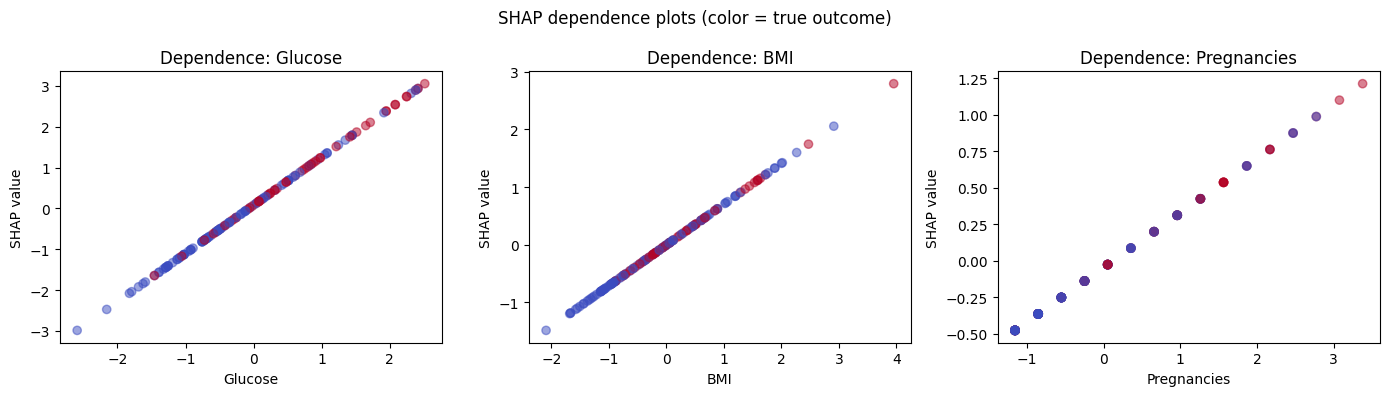

In [20]:
# Dependence plots for top 3 features
top3 = importance_df["feature"].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, feat in enumerate(top3):
    idx = FEATURE_COLS.index(feat)
    axes[i].scatter(X_test_for_shap[:, idx], shap_values[:, idx], alpha=0.5, c=np.asarray(y_test), cmap="coolwarm")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(f"SHAP value")
    axes[i].set_title(f"Dependence: {feat}")
plt.suptitle("SHAP dependence plots (color = true outcome)")
plt.tight_layout()
plt.show()

In [21]:
# Local explanations: pick one TP, FP, TN, FN
proba_test = best_pipe.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

tp_idx = np.where((y_test == 1) & (pred_test == 1))[0][0]
fp_idx = np.where((y_test == 0) & (pred_test == 1))[0][0]
tn_idx = np.where((y_test == 0) & (pred_test == 0))[0][0]
fn_idx = np.where((y_test == 1) & (pred_test == 0))[0][0]

examples = [
    ("True Positive", tp_idx),
    ("False Positive", fp_idx),
    ("True Negative", tn_idx),
    ("False Negative", fn_idx)
]

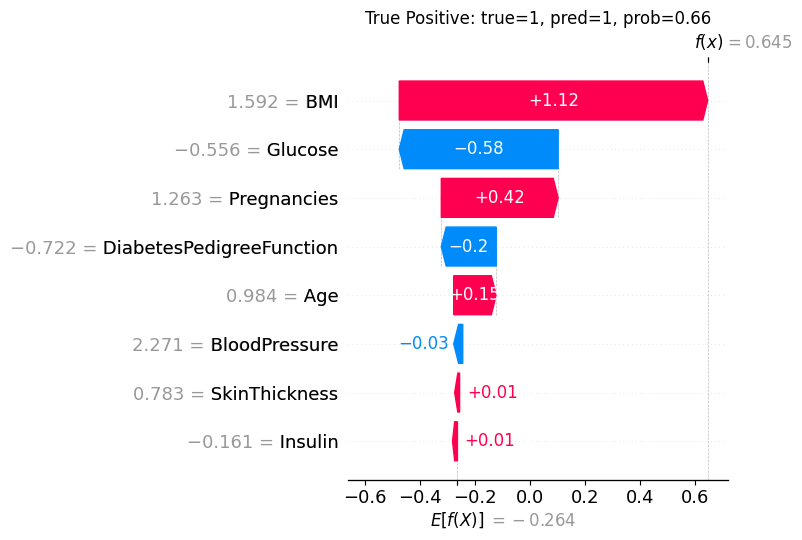

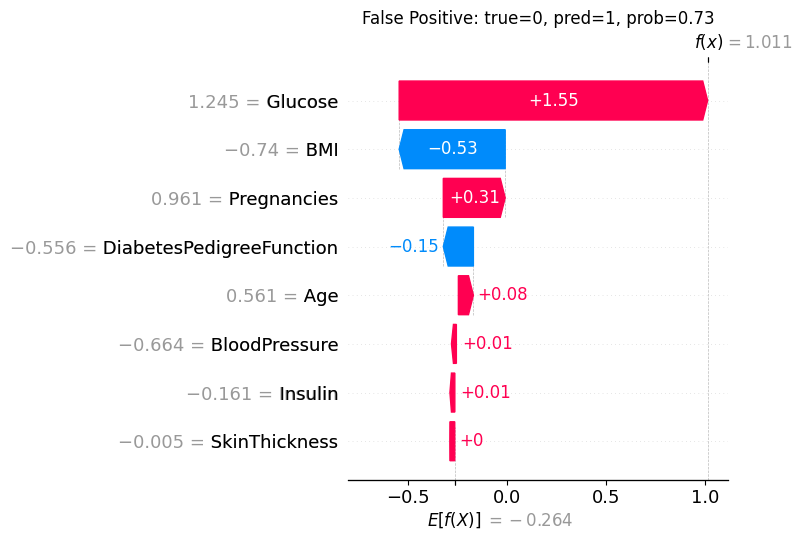

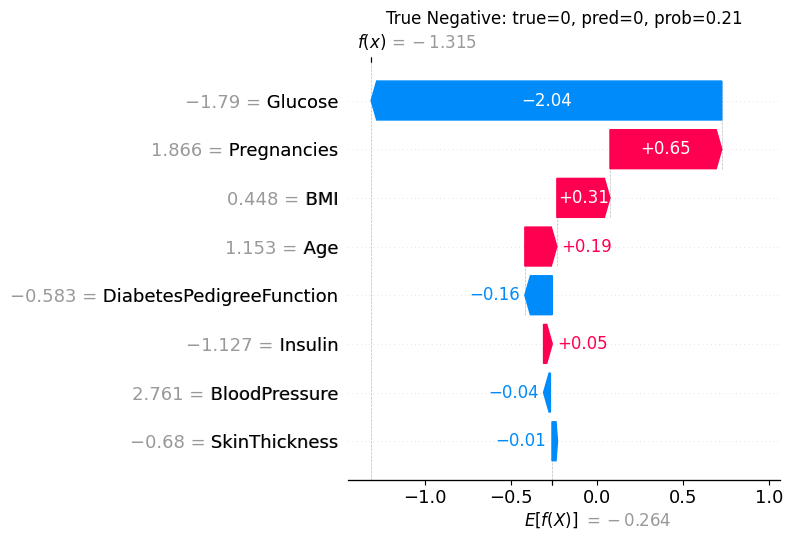

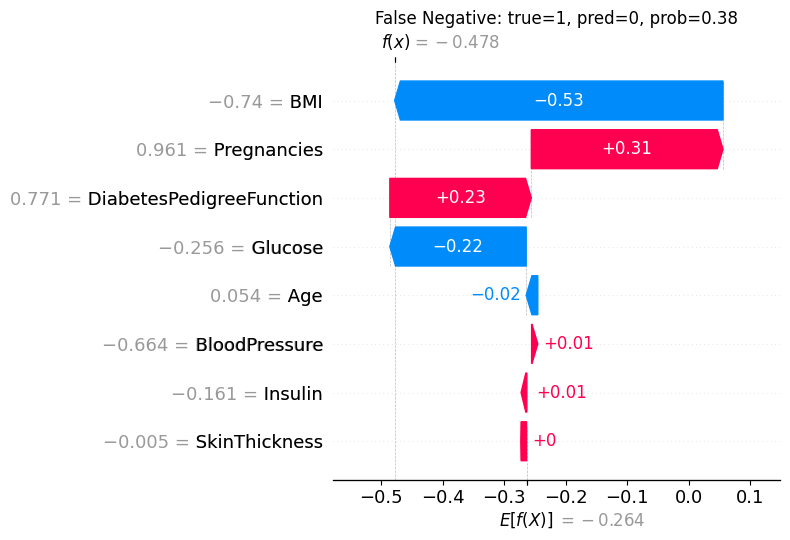

In [22]:
# Waterfall plots for representative cases
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1] if len(base_val) > 1 else base_val[0]

for label, idx in examples:
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=base_val,
        data=X_test_for_shap[idx],
        feature_names=FEATURE_COLS
    )
    true_val = y_test.iloc[idx] if hasattr(y_test, "iloc") else y_test[idx]
    pred_val = pred_test[idx]
    prob_val = proba_test[idx]
    shap.waterfall_plot(exp, max_display=10, show=False)
    plt.title(f"{label}: true={true_val}, pred={pred_val}, prob={prob_val:.2f}")
    plt.tight_layout()
    plt.show()

In [23]:
# Permutation importance (robustness check)
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_pipe, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="roc_auc"
)
perm_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)
print("Permutation importance (ROC-AUC):")
print(perm_df.to_string(index=False))

Permutation importance (ROC-AUC):
                 feature  importance_mean  importance_std
                 Glucose         0.153296        0.032535
                     BMI         0.030556        0.018982
             Pregnancies         0.024741        0.009004
DiabetesPedigreeFunction         0.010111        0.003559
                     Age         0.004481        0.002548
                 Insulin         0.001630        0.001691
           BloodPressure         0.000981        0.000446
           SkinThickness         0.000389        0.000241


## 5. Medical Plausibility and Limitations

### Plausibility checks

- **Glucose**: Higher fasting glucose should increase diabetes risk. Verify in SHAP: higher Glucose → positive SHAP (pushes toward diabetes).
- **BMI**: Higher BMI is a known risk factor. Expect positive association with diabetes prediction.
- **Age**: Diabetes risk increases with age. Expect Age to have positive SHAP for higher values.
- **DiabetesPedigreeFunction**: Family history proxy; higher values should increase risk.
- **Pregnancies**: Gestational diabetes and parity can relate to type 2 risk; direction may vary.
- **Insulin, SkinThickness**: Heavy missingness (zeros as placeholders) may make these unstable; interpret with caution.

### Limitations to discuss

1. **Sample size**: 768 rows → high variance in performance estimates; repeated or nested CV recommended.
2. **Population**: Pima Indians only; not representative of other populations, sexes, or care settings.
3. **Data quality**: Zeros used as missing-value placeholders distort distributions and may bias both predictions and explanations.
4. **Causality**: SHAP explains model behavior, not disease mechanisms; associations are predictive, not causal.
5. **Deployment**: Clinical use would require external validation, calibration review, fairness checks, and richer features.

In [24]:
# Automated plausibility check: direction of top features vs diabetes
# Higher Glucose, BMI, Age, DiabetesPedigreeFunction should generally push toward diabetes (positive SHAP)
for i, feat in enumerate(FEATURE_COLS):
    corr = np.corrcoef(X_test_for_shap[:, i], shap_values[:, i])[0, 1]
    direction = "positive" if corr > 0 else "negative"
    print(f"{feat}: SHAP-feature correlation = {corr:.3f} ({direction})")

Pregnancies: SHAP-feature correlation = 1.000 (positive)
Glucose: SHAP-feature correlation = 1.000 (positive)
BloodPressure: SHAP-feature correlation = -1.000 (negative)
SkinThickness: SHAP-feature correlation = 1.000 (positive)
Insulin: SHAP-feature correlation = -1.000 (negative)
BMI: SHAP-feature correlation = 1.000 (positive)
DiabetesPedigreeFunction: SHAP-feature correlation = 1.000 (positive)
Age: SHAP-feature correlation = 1.000 (positive)
